In [ ]:
#Importing the standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
import seaborn as sns
import os
import random
import re
import shutil
sns.set_style('darkgrid')
sns.set_palette('pastel')

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Defining the input
input_dir='/content/drive/MyDrive/Colab Notebooks/PCB_DATASET/PCB_DATASET'
os.listdir(input_dir)

['rotate.py',
 'rotation',
 'images',
 'Annotations',
 'PCB_USED',
 'images_combined']

In [ ]:
template_dir=os.path.join(input_dir,'PCB_USED')
template_dir

'/content/drive/MyDrive/Colab Notebooks/PCB_DATASET/PCB_DATASET/PCB_USED'

In [ ]:
#Defining the image directory
img_dir=os.path.join(input_dir,'images')

#Listing the types of defects
os.listdir(img_dir)
types_defect=os.listdir(os.path.join(input_dir,'images'))
types_defect

['Open_circuit',
 'Short',
 'Spur',
 'Spurious_copper',
 'Mouse_bite',
 'Missing_hole']

In [ ]:
#Creating an image path list for ready refernce
img_path_list=[]
#Creating img_path list
for sub_cat in types_defect:
    for file in os.listdir(os.path.join(img_dir,sub_cat)):
        img_path_list.append(os.path.join(img_dir,sub_cat,file))

In [ ]:
rotated_dir=os.path.join(input_dir,'rotation')
os.listdir(rotated_dir)

['Spur_angles.txt',
 'Short_angles.txt',
 'Mouse_bite_angles.txt',
 'Spurious_copper_angles.txt',
 'Missing_hole_angles.txt',
 'Open_circuit_angles.txt',
 'Spurious_copper_rotation',
 'Short_rotation',
 'Spur_rotation',
 'Open_circuit_rotation',
 'Missing_hole_rotation',
 'Mouse_bite_rotation']

In [ ]:
rotated_angle_list=[j for j in os.listdir(rotated_dir) if j.endswith('.txt')]
rotated_angle_list

['Spur_angles.txt',
 'Short_angles.txt',
 'Mouse_bite_angles.txt',
 'Spurious_copper_angles.txt',
 'Missing_hole_angles.txt',
 'Open_circuit_angles.txt']

In [ ]:
types_defect_rotated=[j for j in os.listdir(rotated_dir) if j.endswith('.txt')==False]
types_defect_rotated

['Spurious_copper_rotation',
 'Short_rotation',
 'Spur_rotation',
 'Open_circuit_rotation',
 'Missing_hole_rotation',
 'Mouse_bite_rotation']

In [ ]:
annote_dir=os.path.join(input_dir,'Annotations')
annote_dir

'/content/drive/MyDrive/Colab Notebooks/PCB_DATASET/PCB_DATASET/Annotations'

In [ ]:
type_annot=os.listdir(annote_dir)
type_annot

['Spurious_copper',
 'Spur',
 'Mouse_bite',
 'Missing_hole',
 'Short',
 'Open_circuit']

In [ ]:
#Checking the type of files
file_list=os.listdir(os.path.join(annote_dir,'Mouse_bite'))
file_list[0:5]

['12_mouse_bite_06.xml',
 '12_mouse_bite_01.xml',
 '12_mouse_bite_04.xml',
 '12_mouse_bite_02.xml',
 '12_mouse_bite_10.xml']

In [ ]:
#importing xml ET to parse xml file
import xml.etree.ElementTree as ET

In [ ]:
#Parsing XML to return Bounding box dimensions
def parse_xml(xml_file):

    data=[]

    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.find('filename').text
    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)
    for obj in root.findall('object'):
        name = obj.find('name').text
        xmin = int(obj.find('bndbox/xmin').text)
        ymin = int(obj.find('bndbox/ymin').text)
        xmax = int(obj.find('bndbox/xmax').text)
        ymax = int(obj.find('bndbox/ymax').text)

        data.append({
            'filename': filename,
            'width': width,
            'height': height,
            'class': name,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax
        })

    return data

In [ ]:
#Retrieving data for all files
data=[]
all_data=[]

for x in type_annot:
    for file in os.listdir(os.path.join(annote_dir,x)):
        xml_file_path=os.path.join(os.path.join(annote_dir,x),file)
        data=parse_xml(xml_file_path)
        all_data.extend(data)

In [ ]:
#Creating a dataframe to store the annotations
df_annot=pd.DataFrame(all_data)
df_annot

,filename,width,height,class,xmin,ymin,xmax,ymax
0,09_spurious_copper_09.jpg,2775,2159,spurious_copper,1077,536,1189,625
1,09_spurious_copper_09.jpg,2775,2159,spurious_copper,1584,425,1653,543
2,09_spurious_copper_09.jpg,2775,2159,spurious_copper,1100,1110,1146,1181
3,09_spurious_copper_09.jpg,2775,2159,spurious_copper,2533,799,2617,890
4,09_spurious_copper_09.jpg,2775,2159,spurious_copper,681,405,730,502
...,...,...,...,...,...,...,...,...
2954,05_open_circuit_01.jpg,2544,2156,open_circuit,454,625,514,677
2955,05_open_circuit_01.jpg,2544,2156,open_circuit,1587,630,1634,670
2956,04_open_circuit_16.jpg,3056,2464,open_circuit,1718,813,1784,871
2957,04_open_circuit_16.jpg,3056,2464,open_circuit,1964,1239,2041,1299


In [ ]:
 # Don't run this cell multiple times as it will create multiple copies of the images

 import os
 import shutil

 # Path to the main images folder (stored in img_dir)
 img_dir = "/content/drive/MyDrive/Colab Notebooks/PCB_DATASET/PCB_DATASET/images"  # Path to your images folder

# # Define the source directories for each category inside img_dir
source_dirs = [
     os.path.join(img_dir, "Missing_hole"),
     os.path.join(img_dir, "Mouse_bite"),
     os.path.join(img_dir, "Open_circuit"),
     os.path.join(img_dir, "Short"),
     os.path.join(img_dir, "Spur"),
     os.path.join(img_dir, "Spurious_copper")
 ]

# # Define the destination directory for the combined images (Writable location)
 destination_dir = "/content/drive/MyDrive/Colab Notebooks/PCB_DATASET/PCB_DATASET/images_combined/"

# # Create the destination directory if it doesn't exist
 os.makedirs(destination_dir, exist_ok=True)

# # Loop through each source directory and copy all files to the destination
 for source_dir in source_dirs:
     if os.path.exists(source_dir):
         # Get all files in the current directory
         files = os.listdir(source_dir)

#         # Copy each file to the destination directory
         for file in files:
             file_path = os.path.join(source_dir, file)
             if os.path.isfile(file_path):
                 shutil.copy(file_path, destination_dir)
     else:
         print(f"Directory {source_dir} does not exist.")

# # Now check how many files are in the destination folder
 files_in_combined = os.listdir(destination_dir)
 print(f"Number of files copied: {len(files_in_combined)}")

Number of files copied: 693


Text(0.5, 0, 'No of defects in one PCB')

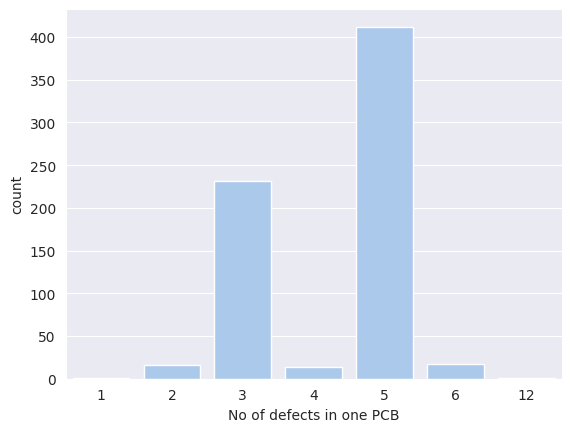

In [ ]:
#Visualizing the no of defects in each pcb
df_multiple_defects=pd.DataFrame(df_annot['filename'].value_counts())
sns.countplot(df_multiple_defects,x='count')
plt.xlabel('No of defects in one PCB')

In [ ]:
#Defining a function to view image along with bounding box

def draw_bounding_boxes(image_path, bounding_boxes,annotation):
    """
    Draws multiple bounding boxes on an image using Matplotlib.

    Args:
        image_path: The path to the image file.
        bounding_boxes: A list of bounding boxes, each represented as a tuple or list containing
                       (min_x, min_y, max_x, max_y).
    """

    # Load the image
    img = plt.imread(image_path)

    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(15,10))

    # Display the image
    ax.imshow(img)

    # Draw each bounding box
    for bbox in bounding_boxes:
        min_x, min_y, max_x, max_y = bbox
        width = max_x - min_x
        height = max_y - min_y
        rect = patches.Rectangle((min_x, min_y), width, height, linewidth=1, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # Calculate the centroid of the bounding box
        centroid_x = (min_x + max_x) / 2
        centroid_y = (min_y + max_y) / 2

        # Add the annotation to the centroid
        ax.annotate( annotation,(centroid_x,centroid_y),(max_x+20,max_y+20),
            fontsize=10,color='white',
            horizontalalignment='right', verticalalignment='top')

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])



    # Show the plot
    plt.show()

In [ ]:
#Getting filename from filepath
filepath=img_path_list[0]
filename=re.sub(r'.+/([\w_]+\.jpg)',r'\1',filepath)

In [ ]:
filepath

'/content/drive/MyDrive/Colab Notebooks/PCB_DATASET/PCB_DATASET/images/Open_circuit/12_open_circuit_10.jpg'

In [ ]:
filename

'12_open_circuit_10.jpg'

In [ ]:
#Defining function to select the a file and return image along with bounding box
def visualize_annotations(list_image_path,df):
    for i in list_image_path:
        filepath=i
        filename=re.sub(r'.+/([\w_]+\.jpg)',r'\1',filepath)
        df_selected=df[df['filename']==filename]
        width=df_selected['width'].values
        height=df_selected['height'].values
        # Corrected: Use 'class' instead of 'class_name'
        class_name=df_selected['class'].values
        xmin=df_selected['xmin'].values
        ymin=df_selected['ymin'].values
        xmax=df_selected['xmax'].values
        ymax=df_selected['ymax'].values

        bbox=zip(xmin,ymin,xmax,ymax)
        draw_bounding_boxes(filepath, bbox,class_name[0])

In [ ]:
random.shuffle(img_path_list)

visualize_annotations(img_path_list[0:5],df_annot)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
destination_dir = "/content/drive/MyDrive/Colab Notebooks/PCB_DATASET/PCB_DATASET/images_combined/"

PyTorch Version: 2.9.0+cpu
Using device: cpu
Preview of the provided annotation DataFrame:
                    filename  width  height       class_name  xmin  ymin  \
0  09_spurious_copper_09.jpg   2775    2159  spurious_copper  1077   536   
1  09_spurious_copper_09.jpg   2775    2159  spurious_copper  1584   425   
2  09_spurious_copper_09.jpg   2775    2159  spurious_copper  1100  1110   
3  09_spurious_copper_09.jpg   2775    2159  spurious_copper  2533   799   
4  09_spurious_copper_09.jpg   2775    2159  spurious_copper   681   405   

   xmax  ymax  
0  1189   625  
1  1653   543  
2  1146  1181  
3  2617   890  
4   730   502  

6 classes detected in the DataFrame: ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']
Number of defects - Train: 2069, Validation: 454, Test: 436

Visualizing a batch of cropped defect patches...


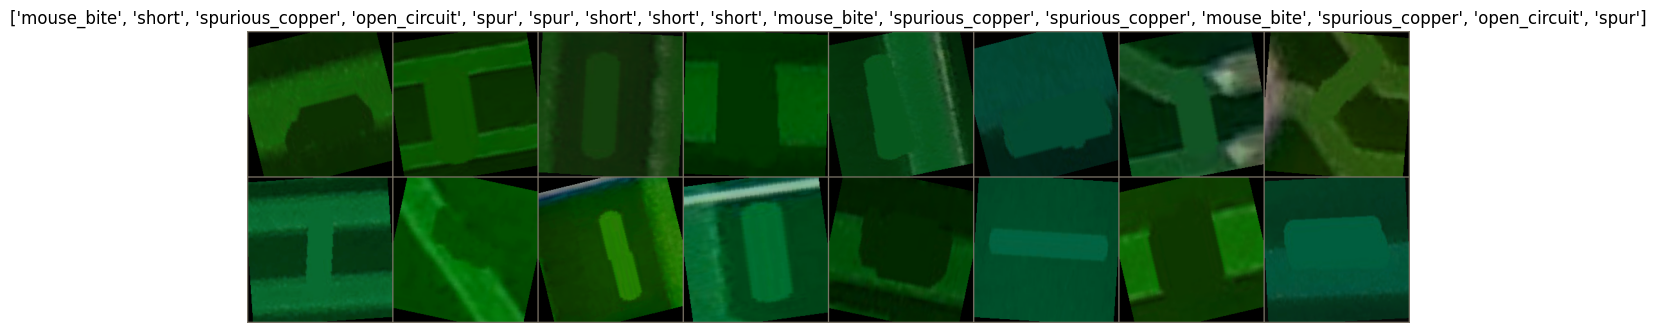

In [ ]:
# ===================================================================
# 1. IMPORTING LIBRARIES AND CONFIGURATION
# ===================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms, utils

from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import time
import copy
import os

# Added for fixing NameError: name 'df_annot' is not defined
import xml.etree.ElementTree as ET

# Basic configuration
print("PyTorch Version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ===================================================================
# 2. DATA PREPARATION (using df_annot and img_dir)
# ===================================================================
# ASSUMING 'df_annot' (DataFrame) AND 'img_dir' (str) ALREADY EXIST.

destination_dir = "/content/drive/MyDrive/Colab Notebooks/PCB_DATASET/PCB_DATASET/images_combined/" # Added for robustness
img_dir = destination_dir

# Re-defining dependencies for df_annot to make this cell self-contained
input_dir = '/content/drive/MyDrive/Colab Notebooks/PCB_DATASET/PCB_DATASET'
annote_dir = os.path.join(input_dir, 'Annotations')
type_annot = os.listdir(annote_dir)

# Definition of parse_xml function
def parse_xml(xml_file):
    data=[]
    tree = ET.parse(xml_file)
    root = tree.getroot()
    filename = root.find('filename').text
    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)
    for obj in root.findall('object'):
        name = obj.find('name').text
        xmin = int(obj.find('bndbox/xmin').text)
        ymin = int(obj.find('bndbox/ymin').text)
        xmax = int(obj.find('bndbox/xmax').text)
        ymax = int(obj.find('bndbox/ymax').text)
        data.append({
            'filename': filename,
            'width': width,
            'height': height,
            'class': name,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax
        })
    return data

# Retrieving data for all files and creating df_annot
all_data=[]
for x in type_annot:
    for file in os.listdir(os.path.join(annote_dir,x)):
        xml_file_path=os.path.join(os.path.join(annote_dir,x),file)
        data=parse_xml(xml_file_path)
        all_data.extend(data)
df_annot=pd.DataFrame(all_data)

# To avoid conflicts with the Python keyword 'class', rename the column
if 'class' in df_annot.columns:
    df_annot = df_annot.rename(columns={'class': 'class_name'})

print("Preview of the provided annotation DataFrame:")
print(df_annot.head())

# Get the list of classes and number of classes
class_names = sorted(df_annot['class_name'].unique())
num_classes = len(class_names)
print(f"\n{num_classes} classes detected in the DataFrame: {class_names}")

# --- Train/Validation/Test split based on FILE NAMES ---
# This is CRUCIAL to avoid data leakage.
unique_filenames = df_annot['filename'].unique()
# 693 images -> train_files : 485 , test_val_files : 208
train_files, test_val_files = train_test_split(unique_filenames, test_size=0.3, random_state=42)
# 208 -> val_files : 104 , test_files : 104
val_files, test_files = train_test_split(test_val_files, test_size=0.5, random_state=42)  # 0.3 * 0.5 = 0.15


# Create DataFrames for each dataset
train_df = df_annot[df_annot['filename'].isin(train_files)].reset_index(drop=True)
val_df = df_annot[df_annot['filename'].isin(val_files)].reset_index(drop=True)
test_df = df_annot[df_annot['filename'].isin(test_files)].reset_index(drop=True)

dataset_sizes = {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}
print(f"Number of defects - Train: {dataset_sizes['train']}, Validation: {dataset_sizes['val']}, Test: {dataset_sizes['test']}")

# --- Data Augmentation and Normalization ---
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),  # Standardize patch size
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# --- Custom Dataset class for cropping images ---
class PCBCropDataset(Dataset):
    def __init__(self, dataframe, image_dir, class_names, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_filename = row['filename']
        box = (row['xmin'], row['ymin'], row['xmax'], row['ymax'])
        label_idx = self.class_to_idx[row['class_name']]

        try:
            img_path = os.path.join(self.image_dir, img_filename)
            image = Image.open(img_path).convert('RGB')
            cropped_image = image.crop(box)
        except FileNotFoundError:
            print(f"Warning: File not found {img_path}. Returning an empty tensor.")
            return torch.zeros((3, 224, 224)), -1  # Handle missing file case

        if self.transform:
            cropped_image = self.transform(cropped_image)

        return cropped_image, label_idx

# --- Create datasets and dataloaders ---
train_dataset = PCBCropDataset(train_df, img_dir, class_names, transform=data_transforms['train'])
val_dataset = PCBCropDataset(val_df, img_dir, class_names, transform=data_transforms['val'])
test_dataset = PCBCropDataset(test_df, img_dir, class_names, transform=data_transforms['val'])

# Use a smaller batch size initially to avoid memory issues
batch_size = 16

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=os.cpu_count()),
    'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count()),
    'test': DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count())
}

# --- Visualize a batch of cropped defect patches ---
print("\nVisualizing a batch of cropped defect patches...")
inputs, classes_idx = next(iter(dataloaders['train']))
out = utils.make_grid(inputs)

# Inverse normalization for display
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean; inp = np.clip(inp, 0, 1)
    plt.figure(figsize=(15, 8)); plt.imshow(inp)
    if title is not None: plt.title(title)
    plt.axis('off'); plt.show()

imshow(out, title=[class_names[x] for x in classes_idx])


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 115MB/s]


Epoch 1/50
--------------------
Train Loss: 1.0415 Acc: 0.6588
Val Loss: 0.8271 Acc: 0.7291
Validation loss improved (inf → 0.8271)

Epoch 2/50
--------------------
Train Loss: 0.5764 Acc: 0.8101
Val Loss: 0.6188 Acc: 0.7687
Validation loss improved (0.8271 → 0.6188)

Epoch 3/50
--------------------
Train Loss: 0.4422 Acc: 0.8574
Val Loss: 0.5427 Acc: 0.7952
Validation loss improved (0.6188 → 0.5427)

Epoch 4/50
--------------------
Train Loss: 0.3478 Acc: 0.8879
Val Loss: 0.4213 Acc: 0.8502
Validation loss improved (0.5427 → 0.4213)

Epoch 5/50
--------------------
Train Loss: 0.3018 Acc: 0.8908
Val Loss: 0.3834 Acc: 0.8546
Validation loss improved (0.4213 → 0.3834)

Epoch 6/50
--------------------
Train Loss: 0.2991 Acc: 0.9067
Val Loss: 0.3502 Acc: 0.8789
Validation loss improved (0.3834 → 0.3502)

Epoch 7/50
--------------------
Train Loss: 0.2538 Acc: 0.9154
Val Loss: 0.3349 Acc: 0.8921
Validation loss improved (0.3502 → 0.3349)

Epoch 8/50
--------------------
Train Loss: 0.2249 

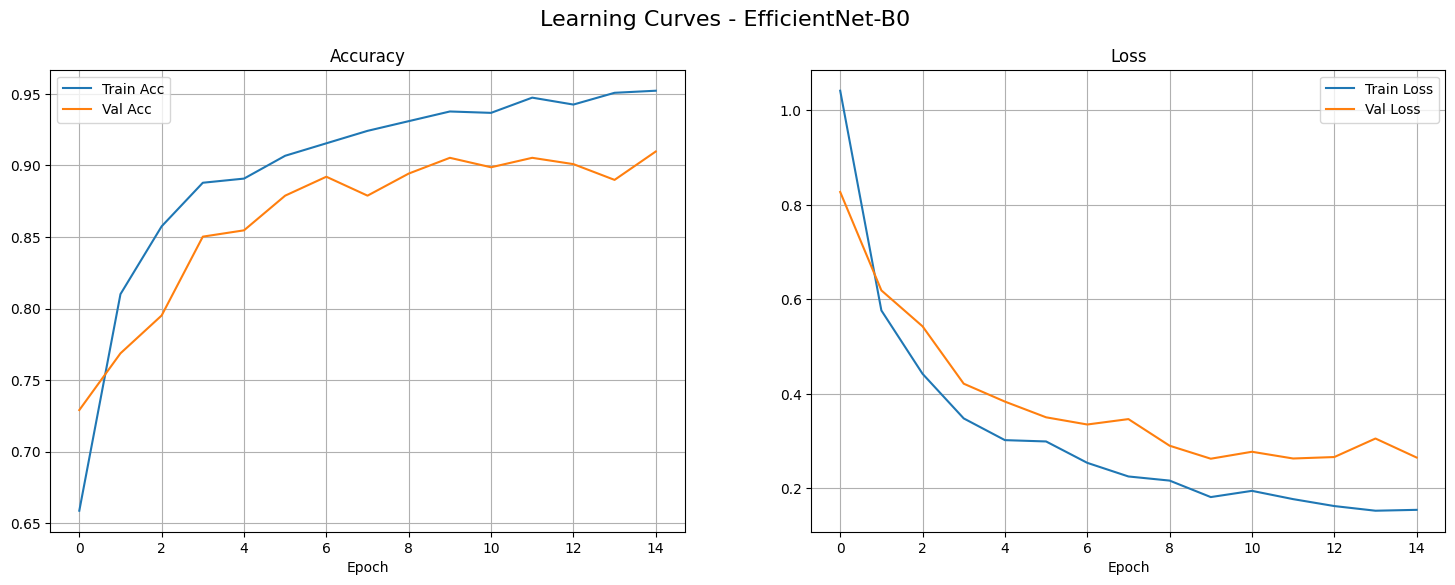


--- Final Evaluation: EfficientNet-B0 ---

                 precision    recall  f1-score   support

   missing_hole     1.0000    1.0000    1.0000        73
     mouse_bite     0.9014    0.9143    0.9078        70
   open_circuit     1.0000    0.8889    0.9412        63
          short     0.9625    0.9625    0.9625        80
           spur     0.8462    0.9016    0.8730        61
spurious_copper     0.9670    0.9888    0.9778        89

       accuracy                         0.9472       436
      macro avg     0.9462    0.9427    0.9437       436
   weighted avg     0.9490    0.9472    0.9475       436



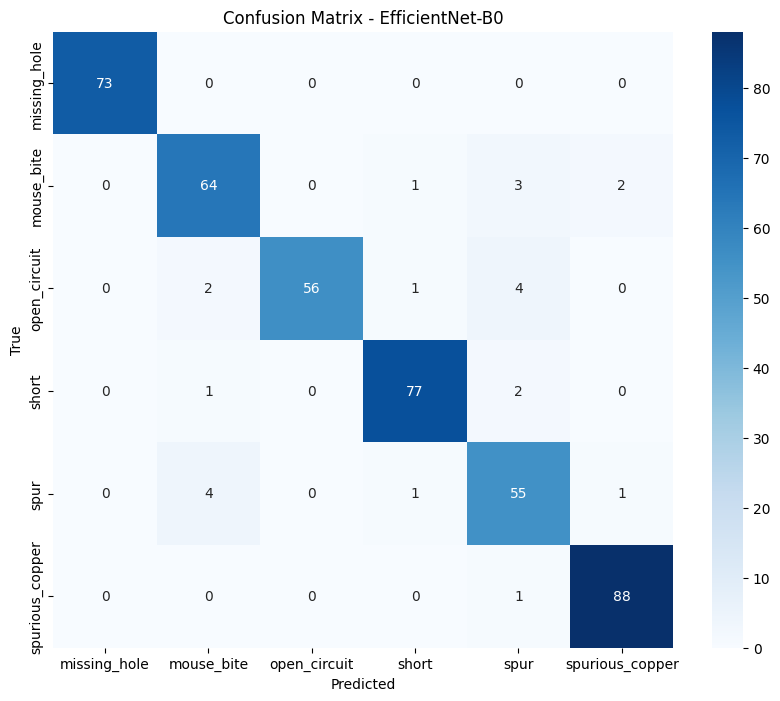

EfficientNet model saved to /content/drive/MyDrive/Colab Notebooks/best_efficientnet_pcb_defects_50epochs.pth


In [5]:
# ===============================================================
# EFFICIENTNET-B0 COMPLETE PIPELINE (SINGLE CELL)
# ===============================================================

import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import xml.etree.ElementTree as ET
import os

from torchvision import models, transforms, utils
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import numpy as np

# Re-defining dependencies for df_annot and other variables to make this cell self-contained
# Basic configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

destination_dir = "/content/drive/MyDrive/Colab Notebooks/PCB_DATASET/PCB_DATASET/images_combined/"
img_dir = destination_dir

input_dir = '/content/drive/MyDrive/Colab Notebooks/PCB_DATASET/PCB_DATASET'
annote_dir = os.path.join(input_dir, 'Annotations')
type_annot = os.listdir(annote_dir)

# Definition of parse_xml function
def parse_xml(xml_file):
    data=[]
    tree = ET.parse(xml_file)
    root = tree.getroot()
    filename = root.find('filename').text
    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)
    for obj in root.findall('object'):
        name = obj.find('name').text
        xmin = int(obj.find('bndbox/xmin').text)
        ymin = int(obj.find('bndbox/ymin').text)
        xmax = int(obj.find('bndbox/xmax').text)
        ymax = int(obj.find('bndbox/ymax').text)
        data.append({
            'filename': filename,
            'width': width,
            'height': height,
            'class': name,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax
        })
    return data

# Retrieving data for all files and creating df_annot
all_data=[]
for x in type_annot:
    for file in os.listdir(os.path.join(annote_dir,x)):
        xml_file_path=os.path.join(os.path.join(annote_dir,x),file)
        data=parse_xml(xml_file_path)
        all_data.extend(data)
df_annot=pd.DataFrame(all_data)

# To avoid conflicts with the Python keyword 'class', rename the column
if 'class' in df_annot.columns:
    df_annot = df_annot.rename(columns={'class': 'class_name'})

class_names = sorted(df_annot['class_name'].unique())
num_classes = len(class_names)

# --- Train/Validation/Test split based on FILE NAMES ---
unique_filenames = df_annot['filename'].unique()
train_files, test_val_files = train_test_split(unique_filenames, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(test_val_files, test_size=0.5, random_state=42)

train_df = df_annot[df_annot['filename'].isin(train_files)].reset_index(drop=True)
val_df = df_annot[df_annot['filename'].isin(val_files)].reset_index(drop=True)
test_df = df_annot[df_annot['filename'].isin(test_files)].reset_index(drop=True)

dataset_sizes = {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}

# --- Data Augmentation and Normalization ---
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# --- Custom Dataset class for cropping images ---
class PCBCropDataset(Dataset):
    def __init__(self, dataframe, image_dir, class_names, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_filename = row['filename']
        box = (row['xmin'], row['ymin'], row['xmax'], row['ymax'])
        label_idx = self.class_to_idx[row['class_name']]

        try:
            img_path = os.path.join(self.image_dir, img_filename)
            image = Image.open(img_path).convert('RGB')
            cropped_image = image.crop(box)
        except FileNotFoundError:
            # Log the warning instead of printing to stderr
            print(f"Warning: File not found {img_path}. Returning an empty tensor.")
            return torch.zeros((3, 224, 224)), -1

        if self.transform:
            cropped_image = self.transform(cropped_image)

        return cropped_image, label_idx

# --- Create datasets and dataloaders ---
batch_size = 16

dataloaders = {
    'train': DataLoader(PCBCropDataset(train_df, img_dir, class_names, transform=data_transforms['train']), batch_size=batch_size, shuffle=True, num_workers=os.cpu_count()),
    'val': DataLoader(PCBCropDataset(val_df, img_dir, class_names, transform=data_transforms['val']), batch_size=batch_size, shuffle=False, num_workers=os.cpu_count()),
    'test': DataLoader(PCBCropDataset(test_df, img_dir, class_names, transform=data_transforms['val']), batch_size=batch_size, shuffle=False, num_workers=os.cpu_count())
}

# ===============================================================
# 3. PRETRAINED MODEL (EfficientNet-B0)
# ===============================================================

def get_pretrained_model(num_classes):
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
    )

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last feature block
    for param in model.features[-1].parameters():
        param.requires_grad = True

    # Unfreeze classifier
    for param in model.classifier.parameters():
        param.requires_grad = True

    # Replace classifier
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, num_classes)

    return model.to(device)

# ===============================================================
# 4. TRAINING AND VALIDATION FUNCTION (WITH EARLY STOPPING)
# ===============================================================

def train_model(model, criterion, optimizer, num_epochs=50, patience=5):
    since = time.time()
    history = {'train_loss': [], 'train_acc': [],
               'val_loss': [], 'val_acc': []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} '
                  f'Acc: {epoch_acc:.4f}')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val':
                if epoch_loss < best_loss:
                    print(f'Validation loss improved '
                          f'({best_loss:.4f} → {epoch_loss:.4f})')
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping after {patience} epochs '
                  f'with no improvement.')
            break

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in '
          f'{time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
    print(f'Best Validation Loss: {best_loss:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

# ===============================================================
# 5. TRAINING EXECUTION
# ===============================================================

efficientnet_model = get_pretrained_model(num_classes)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad,
           efficientnet_model.parameters()),
    lr=0.0005
)

best_efficientnet_model, history = train_model(
    efficientnet_model,
    criterion,
    optimizer,
    num_epochs=50,
    patience=5
)

# ===============================================================
# 6. PLOT LEARNING CURVES
# ===============================================================

def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f"Learning Curves - {model_name}", fontsize=16)

    ax1.plot(history['train_acc'], label='Train Acc')
    ax1.plot(history['val_acc'], label='Val Acc')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['train_loss'], label='Train Loss')
    ax2.plot(history['val_loss'], label='Val Loss')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(True)

    plt.show()

plot_history(history, "EfficientNet-B0")

# ===============================================================
# 7. TEST SET EVALUATION
# ===============================================================

def evaluate_model(model, dataloader, model_name):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    print(f"\n--- Final Evaluation: {model_name} ---\n")
    print(classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4
    ))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

evaluate_model(
    best_efficientnet_model,
    dataloaders['test'],
    "EfficientNet-B0"
)

# ===============================================================
# 8. SAVE MODEL
# ===============================================================

MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/best_efficientnet_pcb_defects_50epochs.pth"

torch.save(
    {
        "model_state_dict": best_efficientnet_model.state_dict(),
        "class_names": class_names
    },
    MODEL_PATH
)

print(f"EfficientNet model saved to {MODEL_PATH}")

In [8]:
# Path where you want to save
MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/best_efficientnet_pcb_defects_50epochs.pth"

# Save only the state_dict (recommended)
torch.save({
    "model_state_dict": best_efficientnet_model.state_dict(),
    "class_names": class_names,
}, MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")

Model saved to /content/drive/MyDrive/Colab Notebooks/best_efficientnet_pcb_defects_50epochs.pth
